# Parte 1 - Análise inicial sem utilização de Técnicas de Feature Engineering

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

# URL do arquivo
url = "https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/credit.csv"

# Especificando a codificação para ler o arquivo CSV
dados_credito = pd.read_csv(url, encoding='ISO-8859-1', sep='\t', low_memory=False)
# or 'ISO-8859-1' if 'latin-1' doesn't work
nomes_cols = ['ID_CLIENTE','TIPO_FUNCIONARIO','DIA_PAGAMENTO','TIPO_ENVIO_APLICACAO','QUANT_CARTOES_ADICIONAIS','TIPO_ENDERECO_POSTAL','SEXO','ESTADO_CIVIL','QUANT_DEPENDENTES',
'NIVEL_EDUCACIONAL','ESTADO_NASCIMENTO','CIDADE_NASCIMENTO','NACIONALIDADE','ESTADO_RESIDENCIAL','CIDADE_RESIDENCIAL','BAIRRO_RESIDENCIAL','FLAG_TELEFONE_RESIDENCIAL',
'CODIGO_AREA_TELEFONE_RESIDENCIAL','TIPO_RESIDENCIA','MESES_RESIDENCIA','FLAG_TELEFONE_MOVEL','FLAG_EMAIL','RENDA_PESSOAL_MENSAL','OUTRAS_RENDAS',
'FLAG_VISA','FLAG_MASTERCARD','FLAG_DINERS','FLAG_AMERICAN_EXPRESS','FLAG_OUTROS_CARTOES','QUANT_CONTAS_BANCARIAS','QUANT_CONTAS_BANCARIAS_ESPECIAIS',
'VALOR_PATRIMONIO_PESSOAL','QUANT_CARROS','EMPRESA','ESTADO_PROFISSIONAL','CIDADE_PROFISSIONAL','BAIRRO_PROFISSIONAL','FLAG_TELEFONE_PROFISSIONAL',
'CODIGO_AREA_TELEFONE_PROFISSIONAL','MESES_NO_TRABALHO','CODIGO_PROFISSAO','TIPO_OCUPACAO','CODIGO_PROFISSAO_CONJUGE','NIVEL_EDUCACIONAL_CONJUGE',
'FLAG_DOCUMENTO_RESIDENCIAL','FLAG_RG','FLAG_CPF','FLAG_COMPROVANTE_RENDA','PRODUTO','FLAG_REGISTRO_ACSP','IDADE','CEP_RESIDENCIAL','CEP_PROFISSIONAL','ROTULO_ALVO_MAU']

dados_credito.columns = nomes_cols

dados_credito.describe()

,ID_CLIENTE,DIA_PAGAMENTO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,NACIONALIDADE,TIPO_RESIDENCIA,MESES_RESIDENCIA,...,TIPO_OCUPACAO,CODIGO_PROFISSAO_CONJUGE,NIVEL_EDUCACIONAL_CONJUGE,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,IDADE,ROTULO_ALVO_MAU
count,49999.000000,49999.000000,49999.0,49999.000000,49999.000000,49999.000000,49999.0,49999.000000,48650.000000,46222.000000,...,42686.000000,21116.000000,17662.000000,49999.0,49999.0,49999.0,49999.0,49999.000000,49999.000000,49999.000000
mean,25001.000000,12.870077,0.0,1.006540,2.148323,0.650513,0.0,0.961599,1.252230,9.727035,...,2.484281,3.797926,0.296003,0.0,0.0,0.0,0.0,1.275706,43.248745,0.260805
std,14433.612391,6.608357,0.0,0.080607,1.322751,1.193666,0.0,0.202107,0.867841,10.668928,...,1.532262,5.212168,0.955688,0.0,0.0,0.0,0.0,0.988295,14.989115,0.439078
min,2.000000,1.000000,0.0,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,6.000000,0.000000
25%,12501.500000,10.000000,0.0,1.000000,1.000000,0.000000,0.0,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,31.000000,0.000000
50%,25001.000000,10.000000,0.0,1.000000,2.000000,0.000000,0.0,1.000000,1.000000,6.000000,...,2.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,41.000000,0.000000
75%,37500.500000,15.000000,0.0,1.000000,2.000000,1.000000,0.0,1.000000,1.000000,15.000000,...,4.000000,11.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,53.000000,1.000000
max,50000.000000,25.000000,0.0,2.000000,7.000000,53.000000,0.0,2.000000,5.000000,228.000000,...,5.000000,17.000000,5.000000,0.0,0.0,0.0,0.0,7.000000,106.000000,1.000000


In [2]:
dados_credito.isnull().sum().sort_values(ascending=True)



# Removendo linhas com valores nulos
dados_credito_limpo = dados_credito.dropna()

# Exibindo a quantidade de valores nulos após a remoção
print(dados_credito_limpo.isnull().sum().sort_values(ascending=True))

dados_credito_limpo.head()

ID_CLIENTE                           0
QUANT_CONTAS_BANCARIAS               0
QUANT_CONTAS_BANCARIAS_ESPECIAIS     0
VALOR_PATRIMONIO_PESSOAL             0
QUANT_CARROS                         0
EMPRESA                              0
ESTADO_PROFISSIONAL                  0
CIDADE_PROFISSIONAL                  0
BAIRRO_PROFISSIONAL                  0
FLAG_TELEFONE_PROFISSIONAL           0
CODIGO_AREA_TELEFONE_PROFISSIONAL    0
MESES_NO_TRABALHO                    0
CODIGO_PROFISSAO                     0
TIPO_OCUPACAO                        0
CODIGO_PROFISSAO_CONJUGE             0
NIVEL_EDUCACIONAL_CONJUGE            0
FLAG_DOCUMENTO_RESIDENCIAL           0
FLAG_RG                              0
FLAG_CPF                             0
FLAG_COMPROVANTE_RENDA               0
PRODUTO                              0
FLAG_REGISTRO_ACSP                   0
IDADE                                0
CEP_RESIDENCIAL                      0
FLAG_OUTROS_CARTOES                  0
FLAG_AMERICAN_EXPRESS    

,ID_CLIENTE,TIPO_FUNCIONARIO,DIA_PAGAMENTO,TIPO_ENVIO_APLICACAO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,SEXO,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,...,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,FLAG_REGISTRO_ACSP,IDADE,CEP_RESIDENCIAL,CEP_PROFISSIONAL,ROTULO_ALVO_MAU
4,6,C,10,0,0,1,M,2,0,0,...,0,0,0,0,2,N,40,371,371,1
8,10,C,5,0,0,1,F,1,0,0,...,0,0,0,0,1,N,41,914,914,0
12,14,C,25,0,0,1,F,2,2,0,...,0,0,0,0,1,N,36,713,713,0
16,18,C,10,0,0,1,F,1,0,0,...,0,0,0,0,1,N,32,267,267,0
23,25,C,10,0,0,1,F,5,0,0,...,0,0,0,0,1,N,47,580,580,0


In [3]:
valores_unicos_sexo = dados_credito_limpo['SEXO'].unique()
valores_unicos_sexo


dados_credito_limpo.loc[dados_credito_limpo["SEXO"].replace(' ', np.nan).isna(), "SEXO"] = 'N'
dados_credito_limpo.head()

,ID_CLIENTE,TIPO_FUNCIONARIO,DIA_PAGAMENTO,TIPO_ENVIO_APLICACAO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,SEXO,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,...,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,FLAG_REGISTRO_ACSP,IDADE,CEP_RESIDENCIAL,CEP_PROFISSIONAL,ROTULO_ALVO_MAU
4,6,C,10,0,0,1,M,2,0,0,...,0,0,0,0,2,N,40,371,371,1
8,10,C,5,0,0,1,F,1,0,0,...,0,0,0,0,1,N,41,914,914,0
12,14,C,25,0,0,1,F,2,2,0,...,0,0,0,0,1,N,36,713,713,0
16,18,C,10,0,0,1,F,1,0,0,...,0,0,0,0,1,N,32,267,267,0
23,25,C,10,0,0,1,F,5,0,0,...,0,0,0,0,1,N,47,580,580,0


In [4]:
# Verificando valores disponíveis pra sexo
dados_credito_limpo['SEXO'].unique()


mapping = {'M': 0, 'F': 1, 'N': 2}
dados_credito_limpo['SEXO'] = dados_credito_limpo['SEXO'].map(mapping)

dados_credito_limpo['SEXO'].unique()

/var/folders/xz/khfgvmxj4tsd1nl_m4gdk7780000gn/T/ipykernel_34979/691337772.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_credito_limpo['SEXO'] = dados_credito_limpo['SEXO'].map(mapping)


array([0, 1, 2])

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


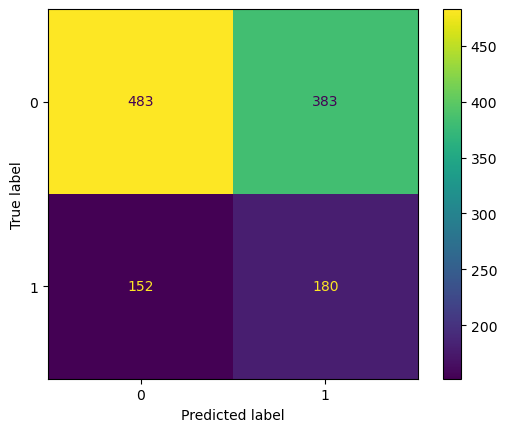

In [5]:
y = dados_credito_limpo["ROTULO_ALVO_MAU"]

# Drop the specified columns
columns_to_drop = ['TIPO_FUNCIONARIO', 'TIPO_ENVIO_APLICACAO', 'ESTADO_NASCIMENTO', 'CIDADE_NASCIMENTO',
                  'ESTADO_RESIDENCIAL', 'CIDADE_RESIDENCIAL', 'BAIRRO_RESIDENCIAL', 'FLAG_TELEFONE_RESIDENCIAL',
                  'CODIGO_AREA_TELEFONE_RESIDENCIAL', 'FLAG_TELEFONE_MOVEL', 'EMPRESA', 'ESTADO_PROFISSIONAL',
                  'CIDADE_PROFISSIONAL', 'BAIRRO_PROFISSIONAL', 'FLAG_TELEFONE_PROFISSIONAL',
                  'CODIGO_AREA_TELEFONE_PROFISSIONAL', 'FLAG_REGISTRO_ACSP', 'CEP_RESIDENCIAL', 'CEP_PROFISSIONAL']
X = dados_credito_limpo.drop(columns=columns_to_drop + ["ROTULO_ALVO_MAU"])


#
## train test split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=50)

model_filter = LogisticRegression(max_iter=1000, class_weight='balanced')
model_filter.fit(X_train,y_train)

y_pred=model_filter.predict(X_test)

metric_filter=confusion_matrix(y_test,y_pred)

cm = confusion_matrix( y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()


In [6]:
print(classification_report(y_test, y_pred, output_dict=False))

              precision    recall  f1-score   support

           0       0.76      0.56      0.64       866
           1       0.32      0.54      0.40       332

    accuracy                           0.55      1198
   macro avg       0.54      0.55      0.52      1198
weighted avg       0.64      0.55      0.58      1198



In [7]:
report_1 = classification_report(y_test, y_pred, output_dict=True)

report_1

{'0': {'precision': 0.7606299212598425,
  'recall': 0.5577367205542725,
  'f1-score': 0.6435709526982012,
  'support': 866.0},
 '1': {'precision': 0.3197158081705151,
  'recall': 0.5421686746987951,
  'f1-score': 0.4022346368715084,
  'support': 332.0},
 'accuracy': 0.5534223706176962,
 'macro avg': {'precision': 0.5401728647151788,
  'recall': 0.5499526976265339,
  'f1-score': 0.5229027947848548,
  'support': 1198.0},
 'weighted avg': {'precision': 0.6384400334921825,
  'recall': 0.5534223706176962,
  'f1-score': 0.5766897700150109,
  'support': 1198.0}}

# Parte 2 - Utilização das técnicas aprendidas durante o curso


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.linear_model import Lasso
from sklearn.metrics import classification_report, confusion_matrix

In [9]:
# Leitura dos dados novamente para testar as técnicas de Feature Engineering
df = pd.read_csv("https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/credit.csv", 
                 encoding='unicode_escape', sep='\t', header=None)

# Definindo nomes das colunas
df.columns = [
    'ID_CLIENTE', 'TIPO_FUNCIONARIO', 'DIA_PAGAMENTO', 'TIPO_ENVIO_APLICACAO', 'QUANT_CARTOES_ADICIONAIS',
    'TIPO_ENDERECO_POSTAL', 'SEXO', 'ESTADO_CIVIL', 'QUANT_DEPENDENTES', 'NIVEL_EDUCACIONAL',
    'ESTADO_NASCIMENTO', 'CIDADE_NASCIMENTO', 'NACIONALIDADE', 'ESTADO_RESIDENCIAL', 'CIDADE_RESIDENCIAL',
    'BAIRRO_RESIDENCIAL', 'FLAG_TELEFONE_RESIDENCIAL', 'CODIGO_AREA_TELEFONE_RESIDENCIAL',
    'TIPO_RESIDENCIA', 'MESES_RESIDENCIA', 'FLAG_TELEFONE_MOVEL', 'FLAG_EMAIL', 'RENDA_PESSOAL_MENSAL',
    'OUTRAS_RENDAS', 'FLAG_VISA', 'FLAG_MASTERCARD', 'FLAG_DINERS', 'FLAG_AMERICAN_EXPRESS',
    'FLAG_OUTROS_CARTOES', 'QUANT_CONTAS_BANCARIAS', 'QUANT_CONTAS_BANCARIAS_ESPECIAIS',
    'VALOR_PATRIMONIO_PESSOAL', 'QUANT_CARROS', 'EMPRESA', 'ESTADO_PROFISSIONAL', 'CIDADE_PROFISSIONAL',
    'BAIRRO_PROFISSIONAL', 'FLAG_TELEFONE_PROFISSIONAL', 'CODIGO_AREA_TELEFONE_PROFISSIONAL',
    'MESES_NO_TRABALHO', 'CODIGO_PROFISSAO', 'TIPO_OCUPACAO', 'CODIGO_PROFISSAO_CONJUGE',
    'NIVEL_EDUCACIONAL_CONJUGE', 'FLAG_DOCUMENTO_RESIDENCIAL', 'FLAG_RG', 'FLAG_CPF',
    'FLAG_COMPROVANTE_RENDA', 'PRODUTO', 'FLAG_REGISTRO_ACSP', 'IDADE', 'CEP_RESIDENCIAL_3',
    'CEP_PROFISSIONAL_3', 'ROTULO_ALVO_MAU'
]

/var/folders/xz/khfgvmxj4tsd1nl_m4gdk7780000gn/T/ipykernel_34979/1185099524.py:2: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/credit.csv",


In [10]:
# 2.1 - Imputação de Dados
# Estratégias diferenciadas por tipo
df['QUANT_DEPENDENTES'] = df['QUANT_DEPENDENTES'].fillna(0)
df['RENDA_PESSOAL_MENSAL'] = df['RENDA_PESSOAL_MENSAL'].fillna(df['RENDA_PESSOAL_MENSAL'].median())
df['OUTRAS_RENDAS'] = df['OUTRAS_RENDAS'].fillna(0)
df['VALOR_PATRIMONIO_PESSOAL'] = df['VALOR_PATRIMONIO_PESSOAL'].fillna(0)
df.fillna('Missing', inplace=True)

print(df.isnull().sum().sort_values(ascending=True))

ID_CLIENTE                           0
QUANT_CONTAS_BANCARIAS               0
QUANT_CONTAS_BANCARIAS_ESPECIAIS     0
VALOR_PATRIMONIO_PESSOAL             0
QUANT_CARROS                         0
EMPRESA                              0
ESTADO_PROFISSIONAL                  0
CIDADE_PROFISSIONAL                  0
BAIRRO_PROFISSIONAL                  0
FLAG_TELEFONE_PROFISSIONAL           0
CODIGO_AREA_TELEFONE_PROFISSIONAL    0
MESES_NO_TRABALHO                    0
CODIGO_PROFISSAO                     0
TIPO_OCUPACAO                        0
CODIGO_PROFISSAO_CONJUGE             0
NIVEL_EDUCACIONAL_CONJUGE            0
FLAG_DOCUMENTO_RESIDENCIAL           0
FLAG_RG                              0
FLAG_CPF                             0
FLAG_COMPROVANTE_RENDA               0
PRODUTO                              0
FLAG_REGISTRO_ACSP                   0
IDADE                                0
CEP_RESIDENCIAL_3                    0
FLAG_OUTROS_CARTOES                  0
FLAG_AMERICAN_EXPRESS    

/var/folders/xz/khfgvmxj4tsd1nl_m4gdk7780000gn/T/ipykernel_34979/3238829299.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Missing' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna('Missing', inplace=True)


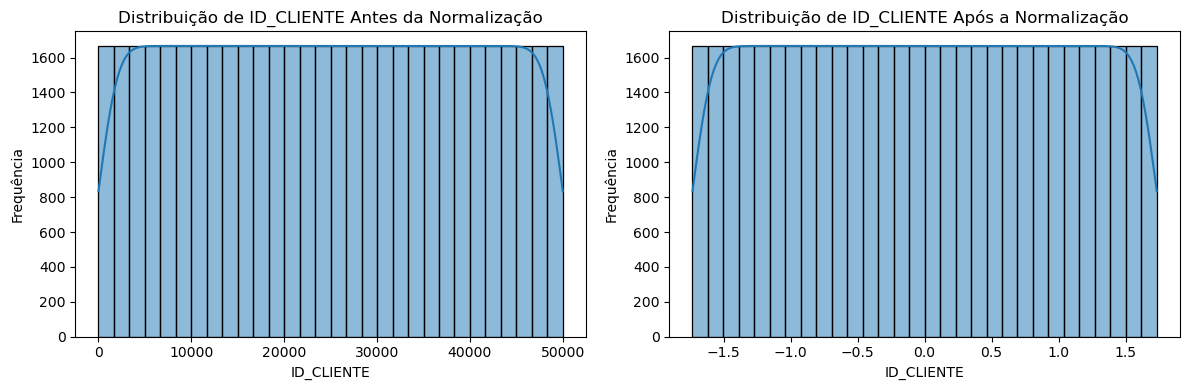

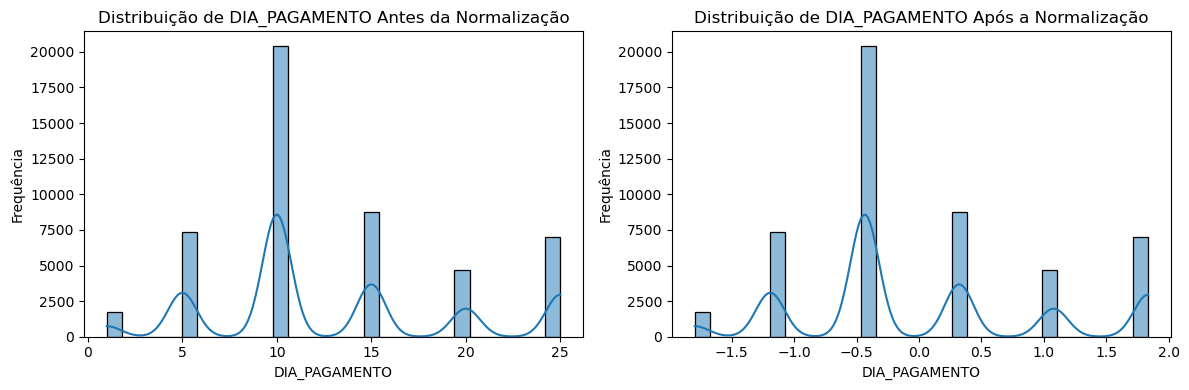

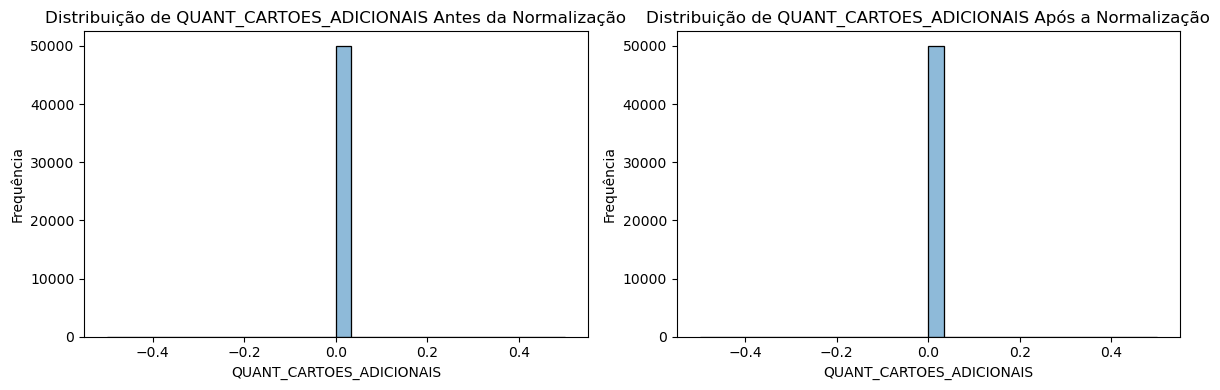

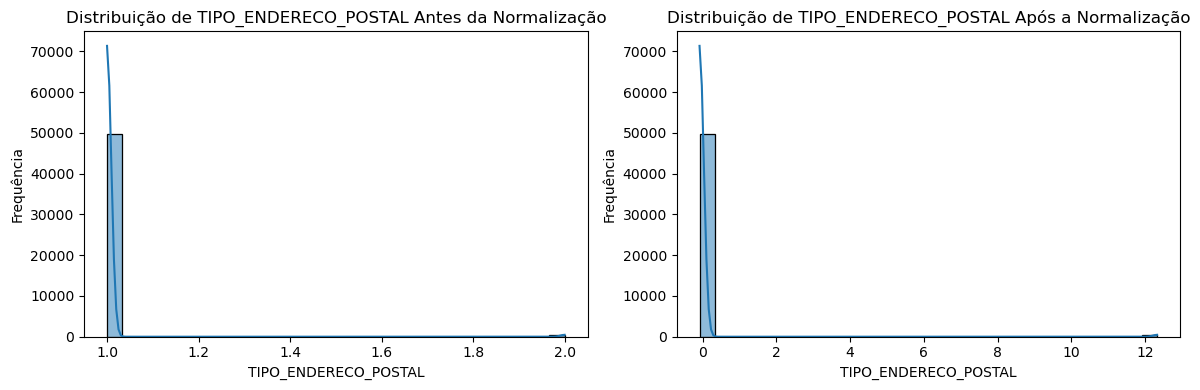

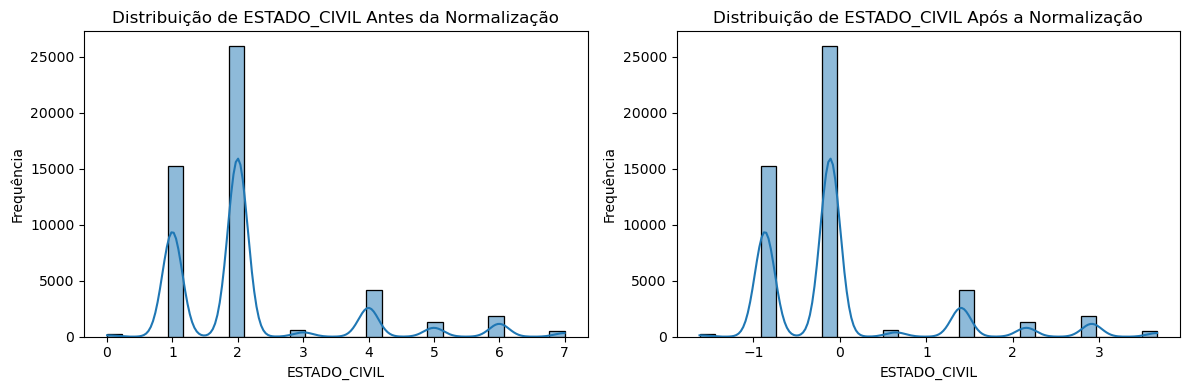

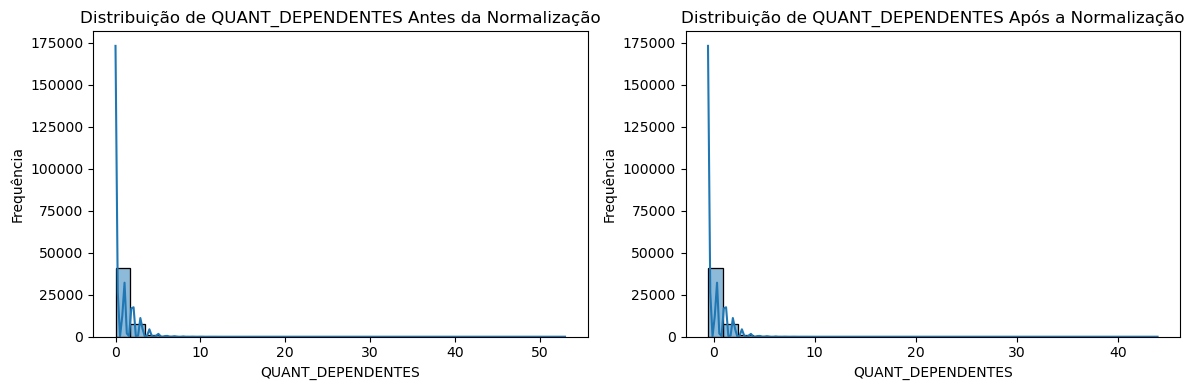

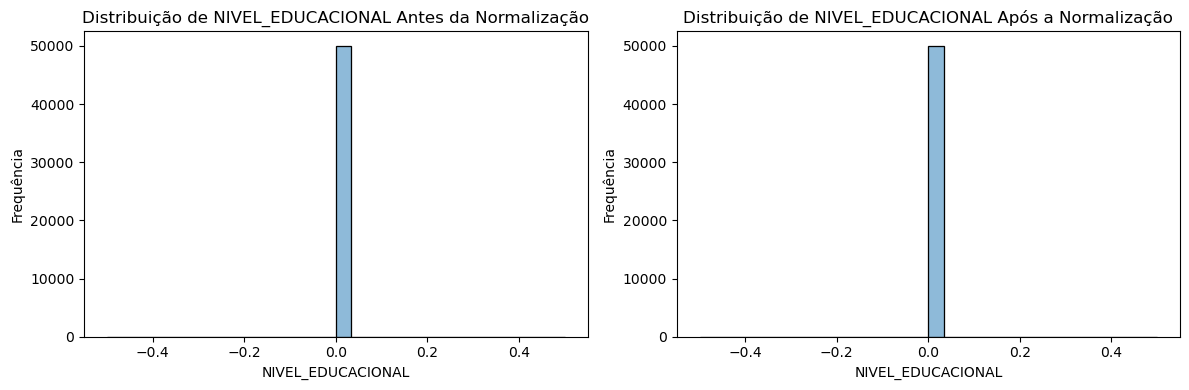

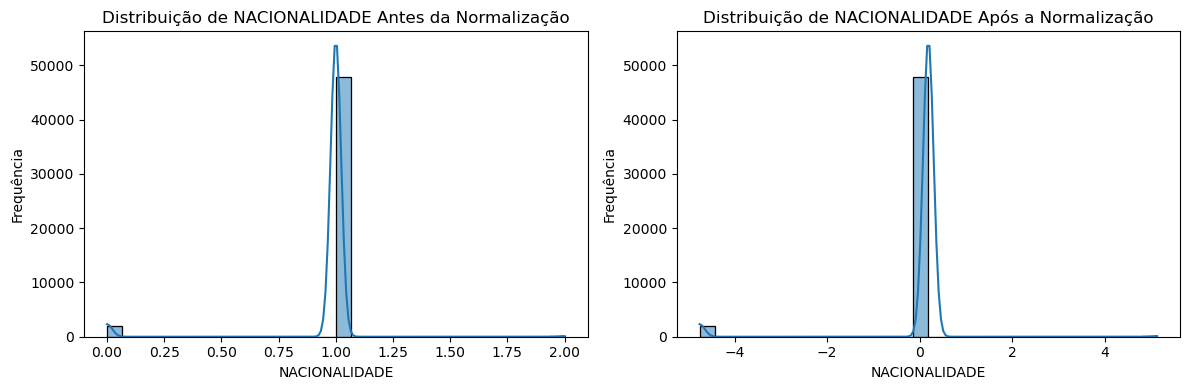

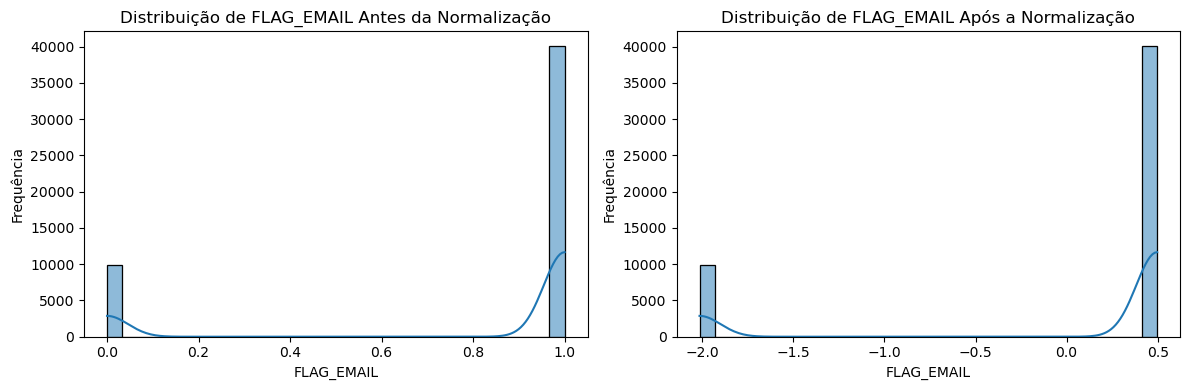

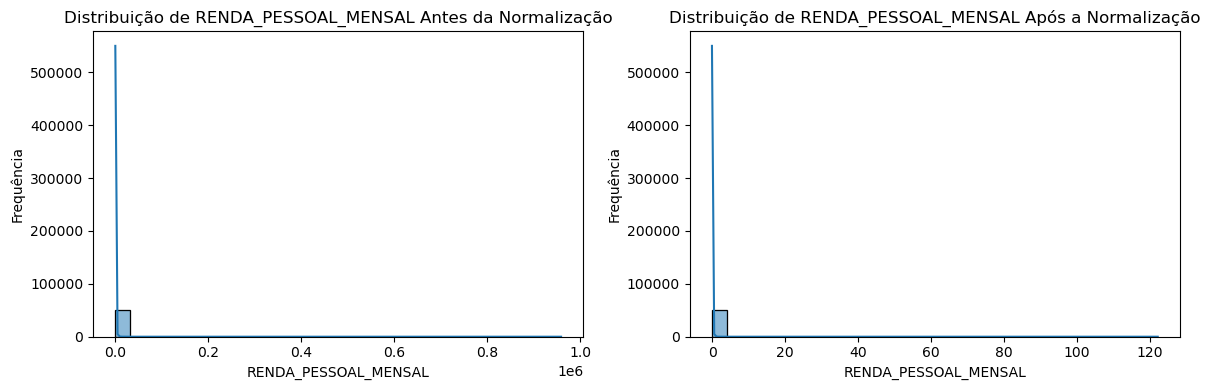

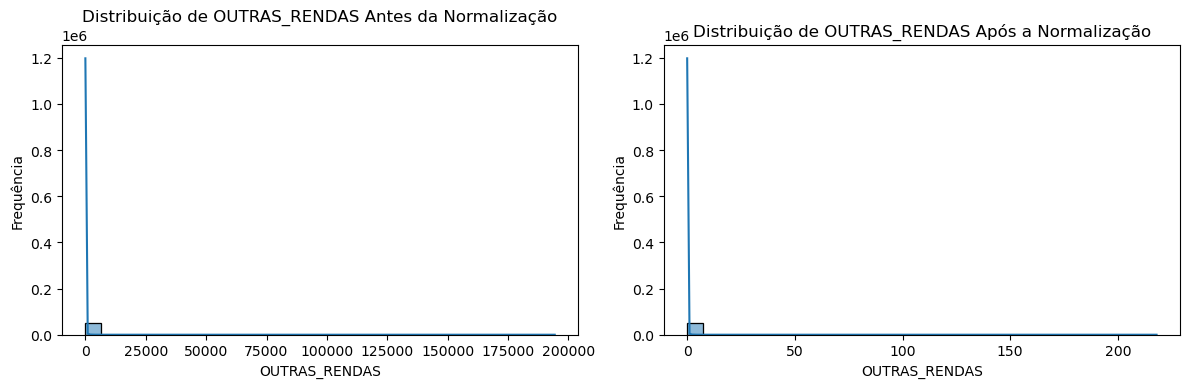

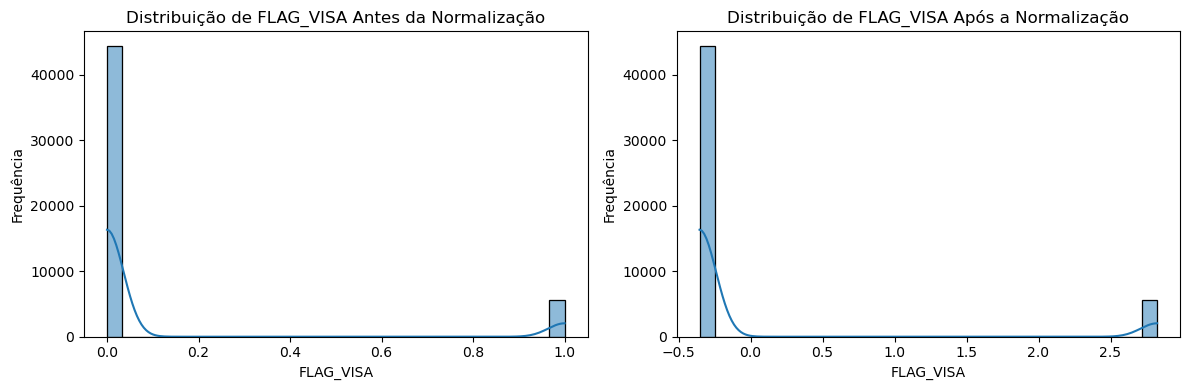

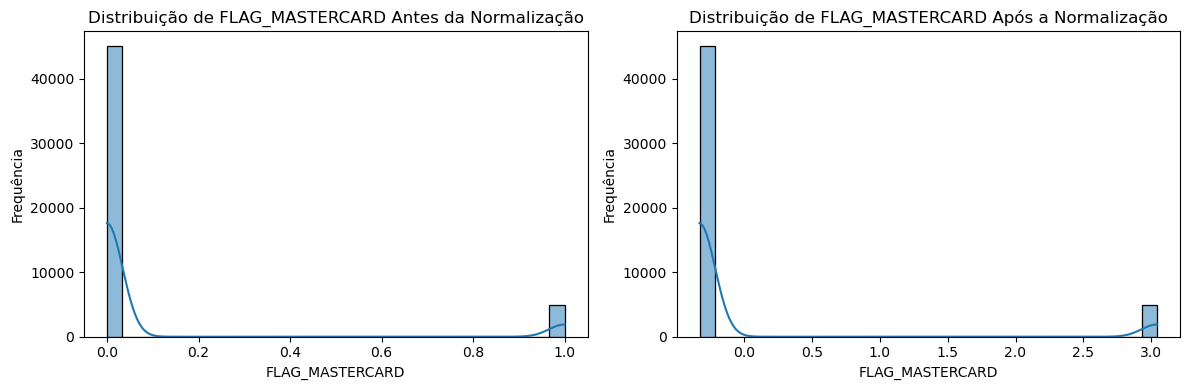

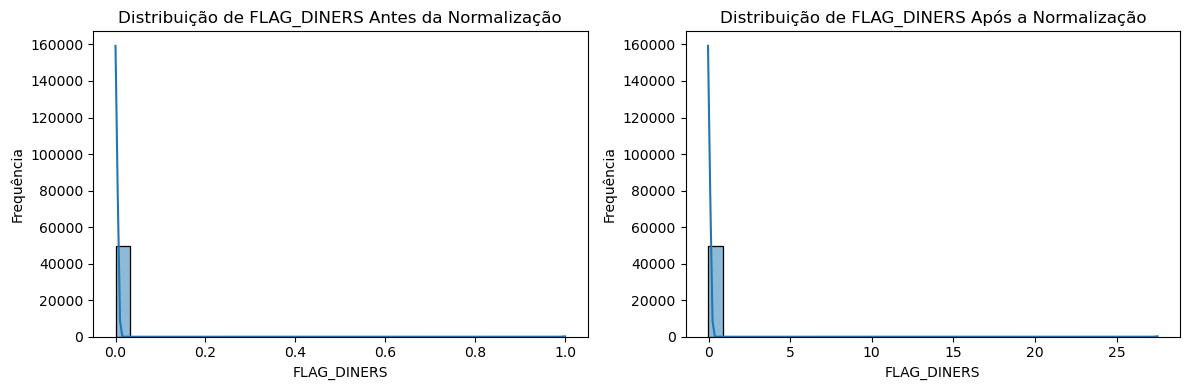

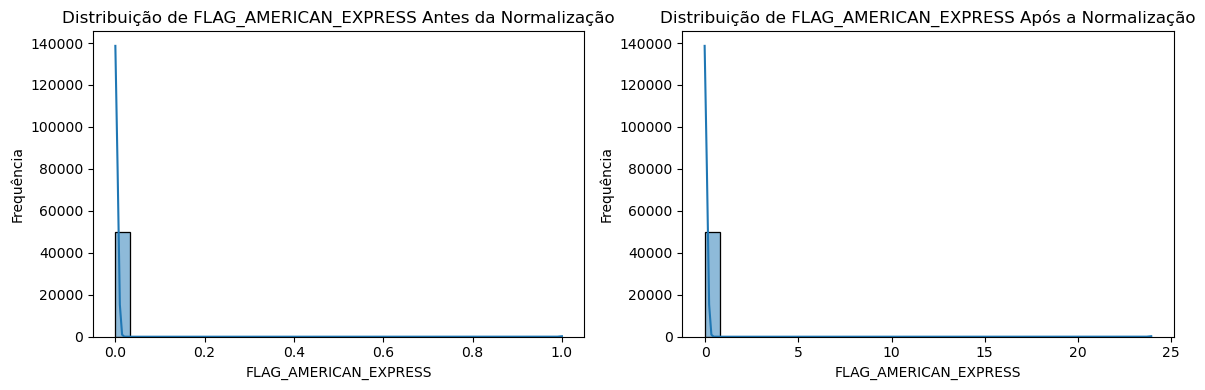

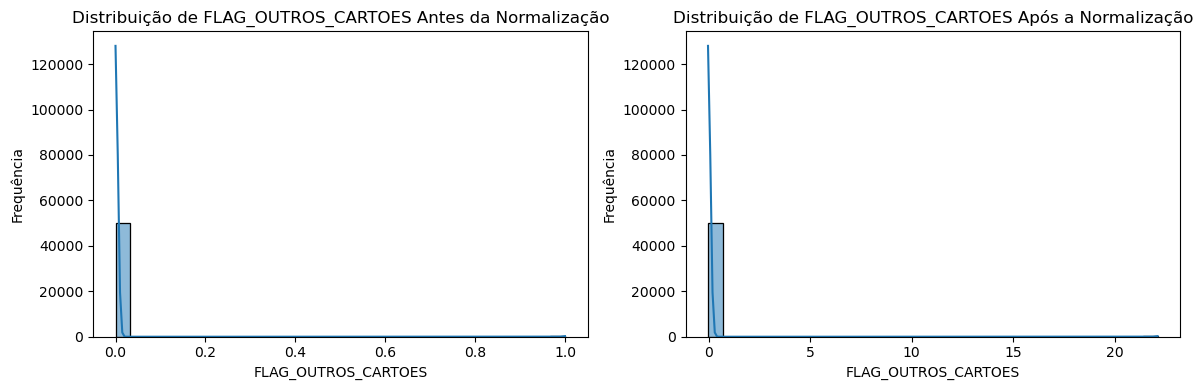

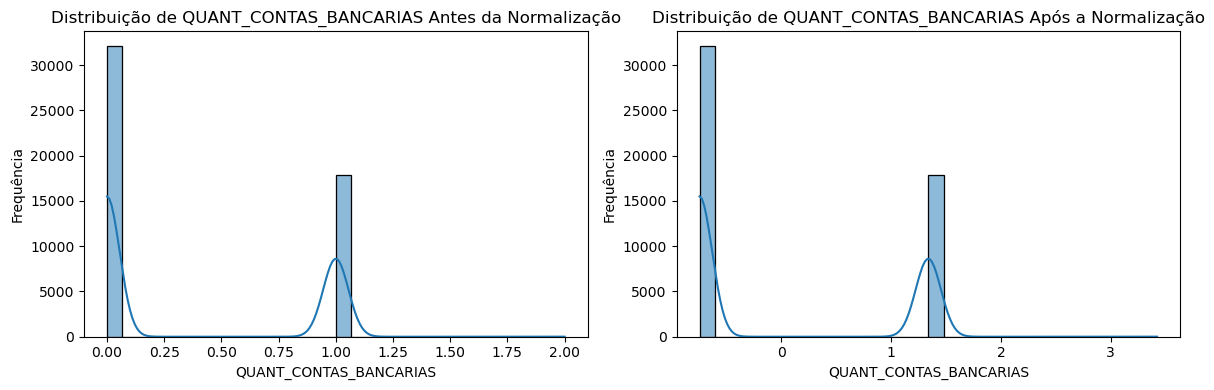

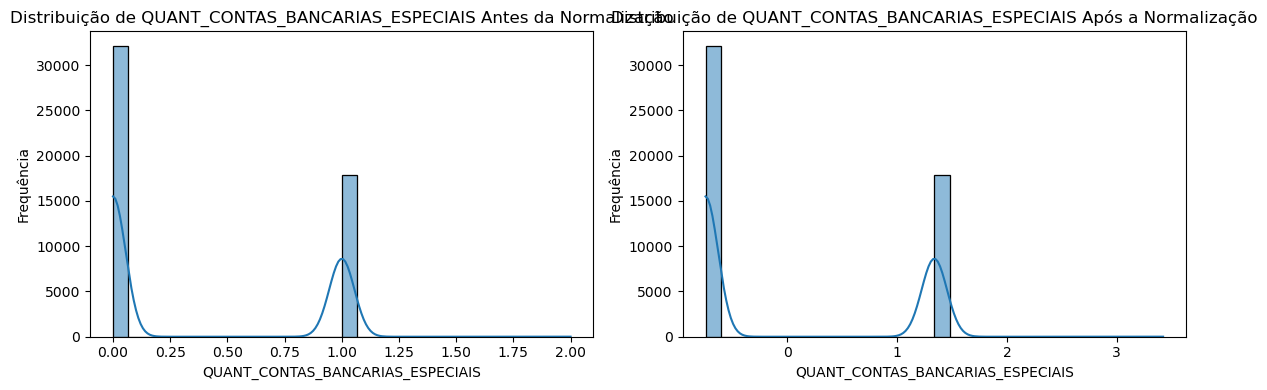

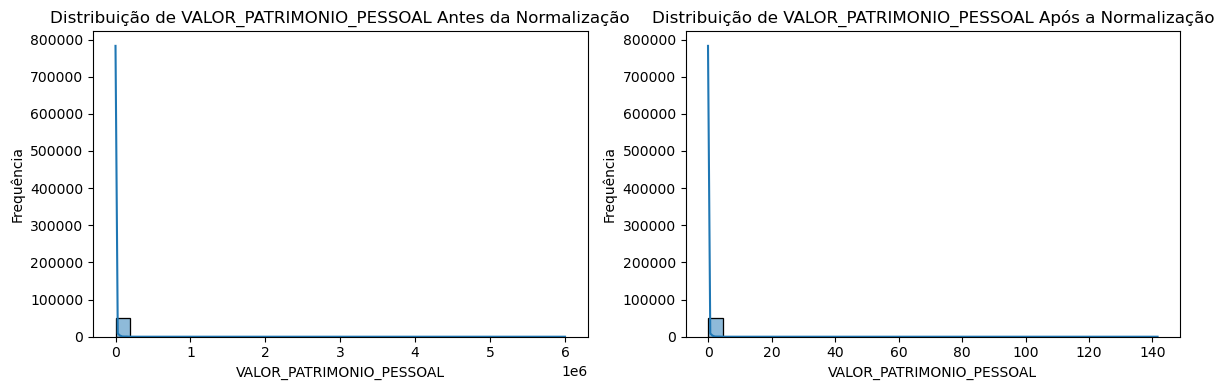

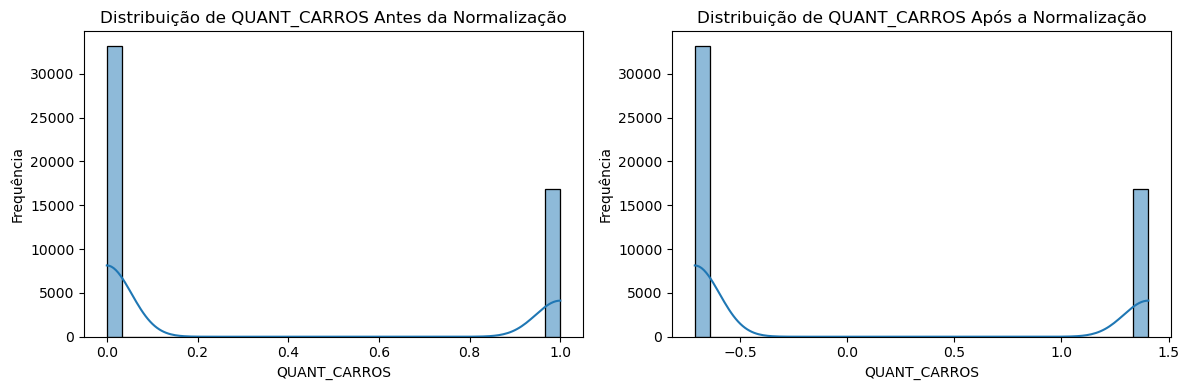

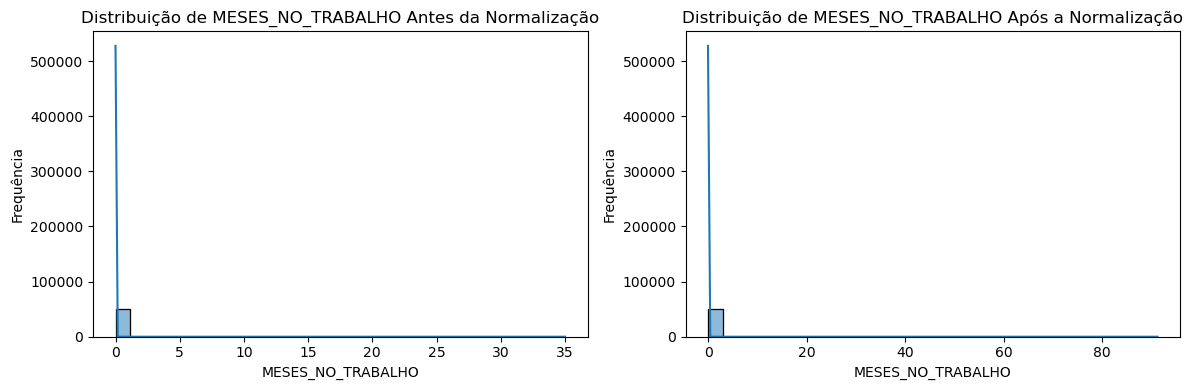

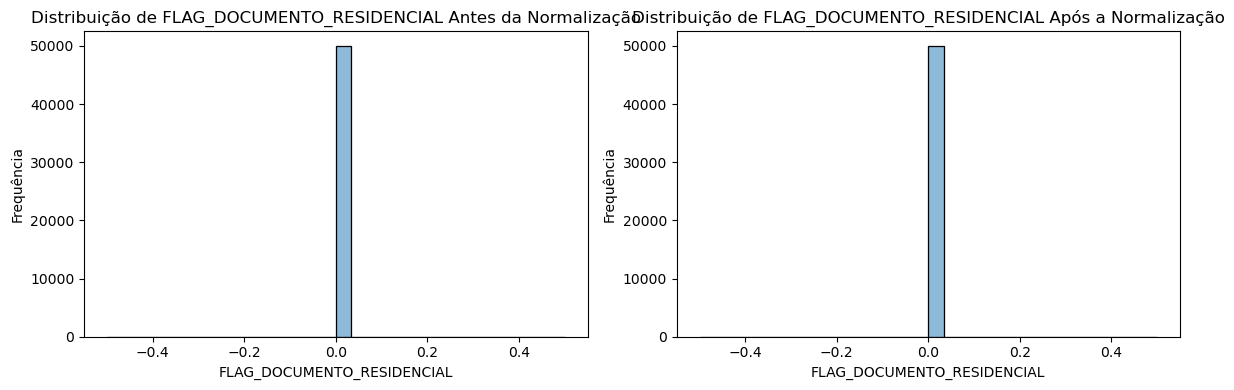

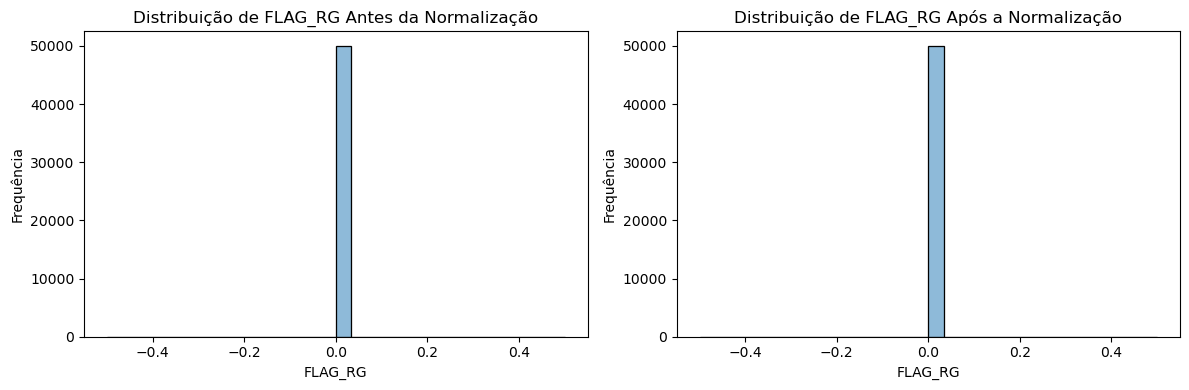

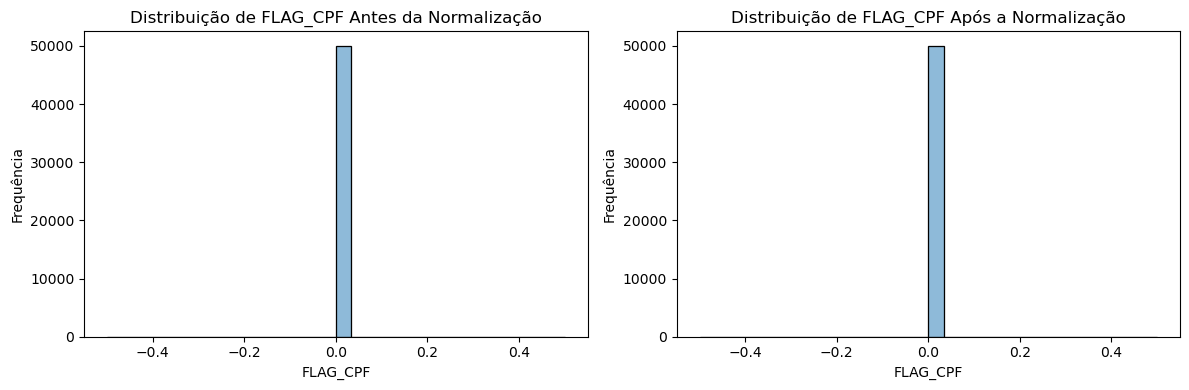

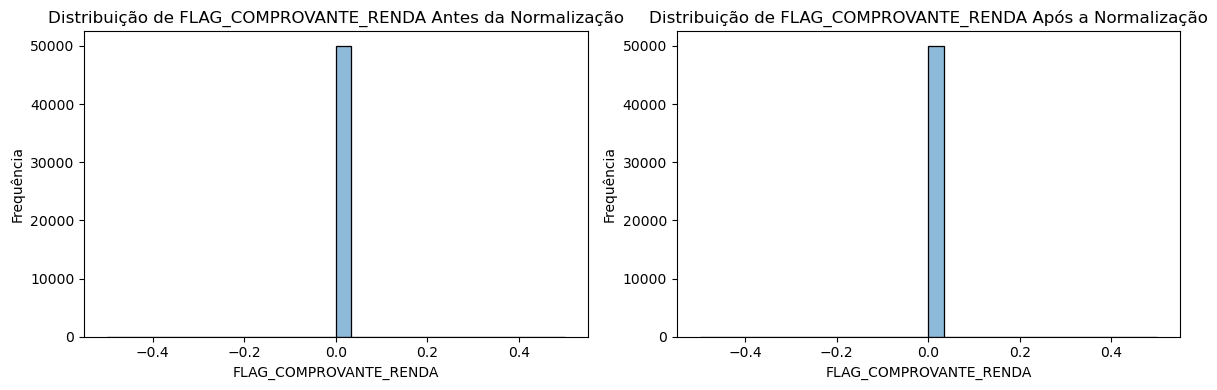

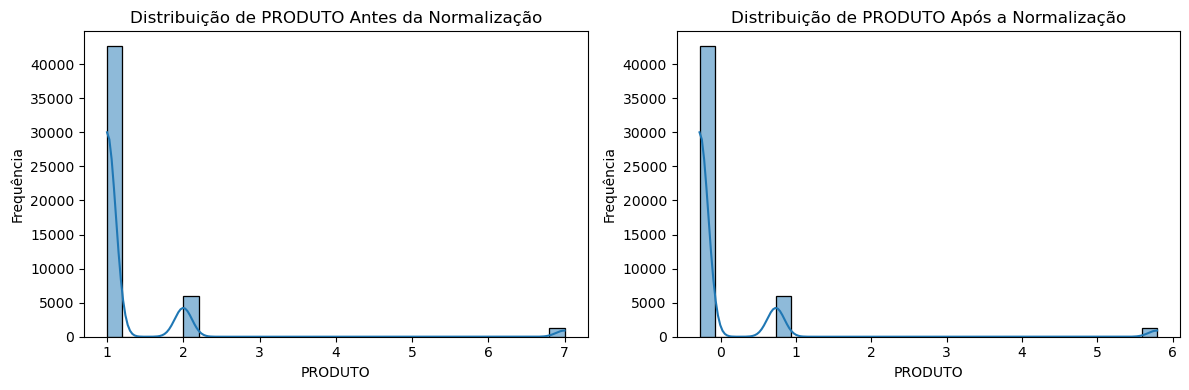

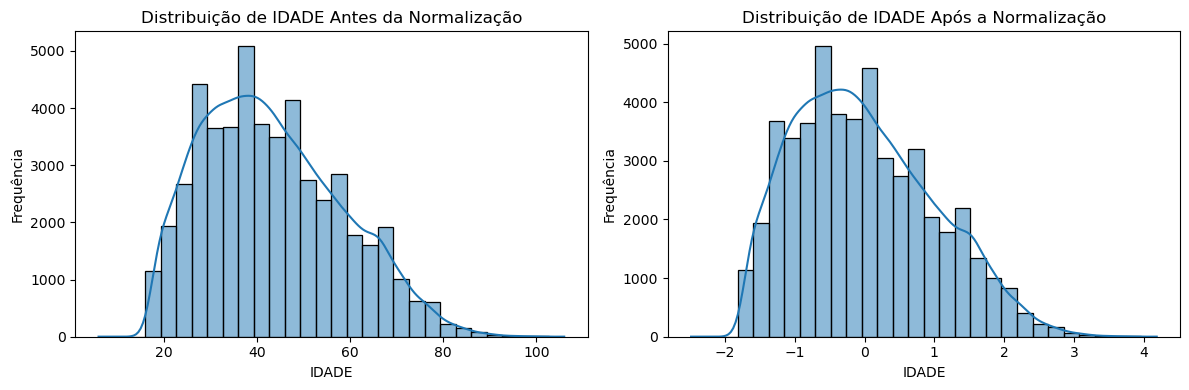

In [11]:
# 2.2 - Normalização dos Dados Numéricos
df_original = df.copy()

# Normalização dos dados
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
num_features.remove('ROTULO_ALVO_MAU')

scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])

# Visualização antes e depois da normalização
for feature in num_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Antes da normalização
    sns.histplot(df_original[feature], bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f'Distribuição de {feature} Antes da Normalização')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Frequência')
    
    # Depois da normalização
    sns.histplot(df[feature], bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f'Distribuição de {feature} Após a Normalização')
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel('Frequência')
    
    plt.tight_layout()
    plt.show()





In [12]:
# 2.3 - Codificação de Variáveis Categóricas

# Identificar as colunas categóricas
cat_features = df.select_dtypes(include=['object']).columns.tolist()

# Aplicar a codificação one-hot
df = pd.get_dummies(df, columns=cat_features, drop_first=True)


print("\nColunas depois da codificação:")
print(df.columns.tolist())




Colunas depois da codificação:
['ID_CLIENTE', 'DIA_PAGAMENTO', 'QUANT_CARTOES_ADICIONAIS', 'TIPO_ENDERECO_POSTAL', 'ESTADO_CIVIL', 'QUANT_DEPENDENTES', 'NIVEL_EDUCACIONAL', 'NACIONALIDADE', 'FLAG_EMAIL', 'RENDA_PESSOAL_MENSAL', 'OUTRAS_RENDAS', 'FLAG_VISA', 'FLAG_MASTERCARD', 'FLAG_DINERS', 'FLAG_AMERICAN_EXPRESS', 'FLAG_OUTROS_CARTOES', 'QUANT_CONTAS_BANCARIAS', 'QUANT_CONTAS_BANCARIAS_ESPECIAIS', 'VALOR_PATRIMONIO_PESSOAL', 'QUANT_CARROS', 'MESES_NO_TRABALHO', 'FLAG_DOCUMENTO_RESIDENCIAL', 'FLAG_RG', 'FLAG_CPF', 'FLAG_COMPROVANTE_RENDA', 'PRODUTO', 'IDADE', 'ROTULO_ALVO_MAU', 'TIPO_ENVIO_APLICACAO_Carga', 'TIPO_ENVIO_APLICACAO_Web', 'SEXO_F', 'SEXO_M', 'SEXO_N', 'ESTADO_NASCIMENTO_AC', 'ESTADO_NASCIMENTO_AL', 'ESTADO_NASCIMENTO_AM', 'ESTADO_NASCIMENTO_AP', 'ESTADO_NASCIMENTO_BA', 'ESTADO_NASCIMENTO_CE', 'ESTADO_NASCIMENTO_DF', 'ESTADO_NASCIMENTO_ES', 'ESTADO_NASCIMENTO_GO', 'ESTADO_NASCIMENTO_MA', 'ESTADO_NASCIMENTO_MG', 'ESTADO_NASCIMENTO_MS', 'ESTADO_NASCIMENTO_MT', 'ESTADO_NASCIM


2.4 - Seleção de Variáveis


/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



2.5 - Nova Modelagem e Avaliação
              precision    recall  f1-score   support

           0       0.74      1.00      0.85     11076
           1       0.20      0.00      0.00      3924

    accuracy                           0.74     15000
   macro avg       0.47      0.50      0.42     15000
weighted avg       0.60      0.74      0.63     15000



/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=30 > n_features=4. There will be no feature selection and all features will be kept.
  warnings.warn(


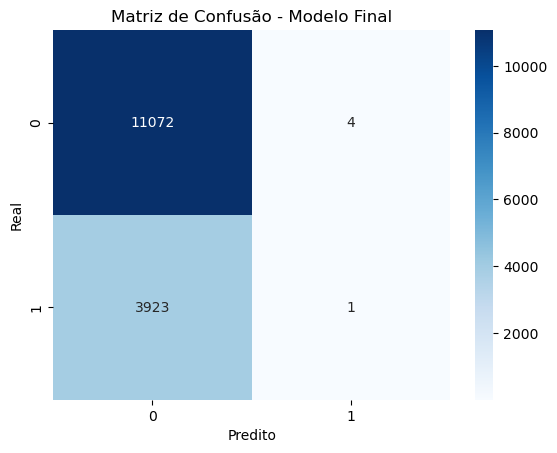

In [13]:
# 2.4 - Seleção de Variáveis (Feature Selection)
print("\n2.4 - Seleção de Variáveis")

X = df.drop(['ROTULO_ALVO_MAU'], axis=1)
y = df['ROTULO_ALVO_MAU']

# Método 1: Correlação
correlation = X.corrwith(y).abs()
selected_features = correlation[correlation > 0.05].index.tolist()

# Método 2: RFE
model = LogisticRegression(max_iter=1000)
rfe = RFE(model, n_features_to_select=30)
rfe.fit(X[selected_features], y)
selected_rfe_features = X[selected_features].columns[rfe.support_]

# 2.5 - Nova Modelagem e Avaliação
print("\n2.5 - Nova Modelagem e Avaliação")

X_train, X_test, y_train, y_test = train_test_split(X[selected_rfe_features], y, test_size=0.3, random_state=42)

final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

print(classification_report(y_test, y_pred_final))

# Matriz de Confusão
conf_matrix = confusion_matrix(y_test, y_pred_final)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Modelo Final')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()